In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


In [3]:
!ls /kaggle/input

datasets


In [4]:
!ls /kaggle/input/datasets

pankrzysiu


In [5]:
!find /kaggle/input -maxdepth 5 -print | head -50

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/pankrzysiu
/kaggle/input/datasets/pankrzysiu/cifar10-python
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-python.tar.gz
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py/readme.html


# NiN Architecture Experiments

This notebook studies the Network in Network (NiN) architecture on the CIFAR-10 image classification task.

The experiments will examine how architectural changes affect the behavior and performance of NiN models.

The same dataset, preprocessing, data augmentation, batch size, optimizer, learning rate, momentum, loss function, initialization, and number of training epochs will be used throughout the experiments unless explicitly stated otherwise.

## Experiment 1: Effect of Depth

In this experiment, I will study how changing the number of NiN blocks affects the performance of the network.

Each NiN block contains:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

The channel configurations are:

| Model | Block 1 | Block 2 | Block 3 | Block 4 |
|---|---:|---:|---:|---:|
| NiN2 | 64 | 128 | — | — |
| NiN3 | 64 | 128 | 256 | — |
| NiN4 | 64 | 128 | 256 | 512 |

The purpose of this experiment is to observe how increasing the depth of the NiN architecture affects its ability to learn and generalize on unseen data.

In [6]:
!git clone https://github.com/davidmba819/cnn-architecture-study.git

Cloning into 'cnn-architecture-study'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 37 (delta 13), reused 28 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 1.44 MiB | 26.29 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [7]:
%cd /kaggle/working/cnn-architecture-study

/kaggle/working/cnn-architecture-study


In [8]:
import sys

sys.path.append("/kaggle/working/cnn-architecture-study")

In [9]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

import cnn_utils

import matplotlib.pyplot as plt

In [10]:
!find /kaggle/input -type d -name "cifar-10-batches-py"

/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py


In [11]:
DATA_DIR = !find /kaggle/input -type d -name "cifar-10-batches-py"
DATA_DIR = DATA_DIR[0].replace("/cifar-10-batches-py", "")

print(DATA_DIR)

/kaggle/input/datasets/pankrzysiu/cifar10-python


In [12]:
from torchvision import datasets


train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=None
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=None
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


In [13]:
train_transform, eval_transform = cnn_utils.create_transforms()

In [14]:
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [15]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data,
    val_data,
    test_dataset,
    train_transform,
    eval_transform,
    batch_size=64,
    num_workers=2
)

In [16]:
images, labels = next(iter(train_loader))

print(f"Images: {images.shape}")
print(f"Labels: {labels.shape}")

Images: torch.Size([64, 3, 32, 32])
Labels: torch.Size([64])


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [17]:
class NiNBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            # Spatial feature extraction
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # 1x1 convolution
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=1
            ),
            nn.ReLU(),

            # 1x1 convolution
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=1
            ),
            nn.ReLU(),

            # Downsampling
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Conv2d):

                nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

In [19]:
class NiN(nn.Module):

    def __init__(self, channels):
        super().__init__()

        blocks = []
        in_channels = 3

        for out_channels in channels:

            blocks.append(
                NiNBlock(
                    in_channels,
                    out_channels
                )
            )

            in_channels = out_channels

        self.blocks = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        linear_layer = self.classifier[2]

        nn.init.xavier_normal_(linear_layer.weight)
        nn.init.zeros_(linear_layer.bias)

    def forward(self, x):

        x = self.blocks(x)
        x = self.classifier(x)

        return x

In [20]:
model = NiN([64, 128])

In [21]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [28]:
model, history_nin2 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8479 | Train Acc: 0.3030 | Val Loss: 1.6471 | Val Acc: 0.3964
Epoch [2/20] Train Loss: 1.5761 | Train Acc: 0.4179 | Val Loss: 1.4514 | Val Acc: 0.4760
Epoch [3/20] Train Loss: 1.4285 | Train Acc: 0.4855 | Val Loss: 1.3640 | Val Acc: 0.4918
Epoch [4/20] Train Loss: 1.3231 | Train Acc: 0.5238 | Val Loss: 1.2311 | Val Acc: 0.5641
Epoch [5/20] Train Loss: 1.2387 | Train Acc: 0.5608 | Val Loss: 1.1958 | Val Acc: 0.5639
Epoch [6/20] Train Loss: 1.1696 | Train Acc: 0.5807 | Val Loss: 1.1243 | Val Acc: 0.5947
Epoch [7/20] Train Loss: 1.1073 | Train Acc: 0.6088 | Val Loss: 1.1088 | Val Acc: 0.5978
Epoch [8/20] Train Loss: 1.0522 | Train Acc: 0.6258 | Val Loss: 1.1127 | Val Acc: 0.6041
Epoch [9/20] Train Loss: 1.0070 | Train Acc: 0.6450 | Val Loss: 0.9629 | Val Acc: 0.6636
Epoch [10/20] Train Loss: 0.9709 | Train Acc: 0.6583 | Val Loss: 0.9657 | Val Acc: 0.6593
Epoch [11/20] Train Loss: 0.9264 | Train Acc: 0.6739 | Val Loss: 0.9057 | Val Acc: 0.6758
Epoch [12/20] Train

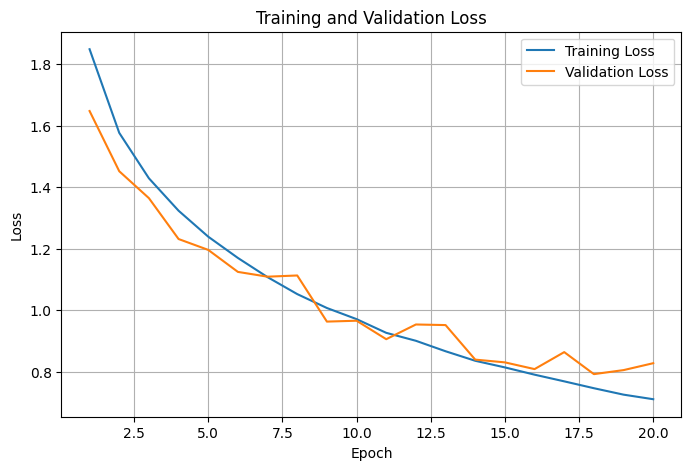

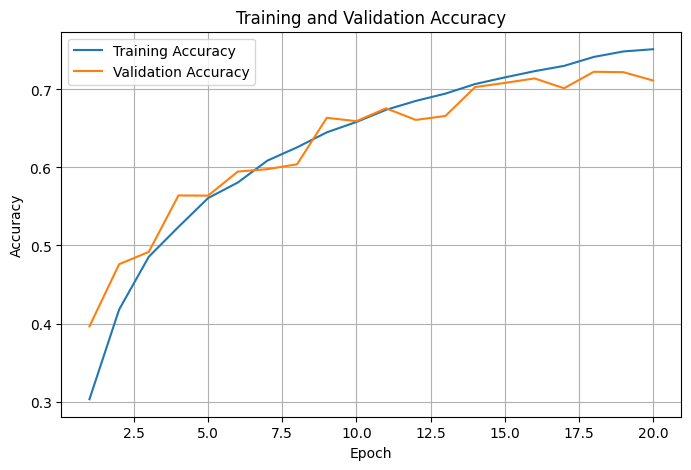

In [29]:
cnn_utils.plot_history(history_nin2)

In [30]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.8343
Test Accuracy: 0.7097
Test loss: 0.8343
Test accuracy: 70.97%


## NiN2 Results

NiN2 was trained for 20 epochs using the same training conditions used throughout the CNN architecture experiments. The model contains two NiN blocks with **64 and 128 channels** respectively.

### Training Results

The model improved steadily throughout the training period.

- Final training loss: **0.7106**
- Final validation loss: **0.8277**
- Final training accuracy: **75.15%**
- Final validation accuracy: **71.14%**

The training loss decreased smoothly throughout the 20 epochs, while the validation loss also decreased overall but showed some fluctuations during the later epochs.

Training accuracy increased steadily from 30.30% in the first epoch to 75.15% by the final epoch. Validation accuracy also improved overall, although it fluctuated more than the training accuracy.

The validation accuracy reached its highest value of approximately **72.62%** around epoch 18 before decreasing slightly toward the end of training.

The gap between the final training accuracy and validation accuracy was approximately **4 percentage points**, which is relatively small compared with the larger gaps observed in some of the deeper VGG experiments.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.8343**
- Test accuracy: **70.97%**

The test accuracy was very close to the final validation accuracy of 71.14%.

### Observation

NiN2 was able to learn the CIFAR-10 classification task, reaching **75.15% training accuracy** and **71.14% validation accuracy** after 20 epochs.

The relatively small gap between training and validation accuracy suggests that the model did not show severe overfitting during this experiment.

The validation accuracy fluctuated during the later epochs and appeared to level off around the low 70% range. However, 20 epochs is not enough to conclude that the model has reached its maximum possible performance.

The test accuracy of **70.97%** was close to the validation accuracy, indicating similar performance on the unseen test data.

These results will serve as the baseline for comparison with the deeper **NiN3** and **NiN4** models.

## NiN3

NiN3 is the second model in the depth experiment. It contains **three NiN blocks** with 64, 128, and 256 channels respectively.

The architecture is:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

This block is repeated three times, with the number of channels increasing from **64 → 128 → 256**.

### Purpose

The purpose of training NiN3 is to determine how increasing the depth of the NiN architecture from two blocks to three blocks affects its learning behavior and generalization.

All training conditions remain exactly the same as NiN2:

- CIFAR-10 dataset
- Same train/validation split
- Same data augmentation
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Same weight initialization

The only architectural change is the addition of the third NiN block.

### NiN3 Configuration

| Model | Block 1 | Block 2 | Block 3 |
|---|---:|---:|---:|
| NiN3 | 64 | 128 | 256 |

The results from NiN3 will be compared with NiN2 to observe whether increasing depth improves the model's ability to learn and generalize on the CIFAR-10 test set.

In [31]:
model = NiN([64, 128, 256])

In [32]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01,  momentum=0.9)

In [34]:
model, history_nin3 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8223 | Train Acc: 0.3128 | Val Loss: 1.6627 | Val Acc: 0.3725
Epoch [2/20] Train Loss: 1.4653 | Train Acc: 0.4615 | Val Loss: 1.2884 | Val Acc: 0.5399
Epoch [3/20] Train Loss: 1.2788 | Train Acc: 0.5397 | Val Loss: 1.2250 | Val Acc: 0.5674
Epoch [4/20] Train Loss: 1.1305 | Train Acc: 0.5968 | Val Loss: 1.1677 | Val Acc: 0.5827
Epoch [5/20] Train Loss: 1.0099 | Train Acc: 0.6439 | Val Loss: 1.0403 | Val Acc: 0.6216
Epoch [6/20] Train Loss: 0.9190 | Train Acc: 0.6751 | Val Loss: 0.8761 | Val Acc: 0.6889
Epoch [7/20] Train Loss: 0.8494 | Train Acc: 0.7026 | Val Loss: 0.8954 | Val Acc: 0.6806
Epoch [8/20] Train Loss: 0.7864 | Train Acc: 0.7264 | Val Loss: 0.7747 | Val Acc: 0.7271
Epoch [9/20] Train Loss: 0.7172 | Train Acc: 0.7466 | Val Loss: 0.7528 | Val Acc: 0.7361
Epoch [10/20] Train Loss: 0.6728 | Train Acc: 0.7672 | Val Loss: 0.7668 | Val Acc: 0.7299
Epoch [11/20] Train Loss: 0.6248 | Train Acc: 0.7834 | Val Loss: 0.6776 | Val Acc: 0.7658
Epoch [12/20] Train

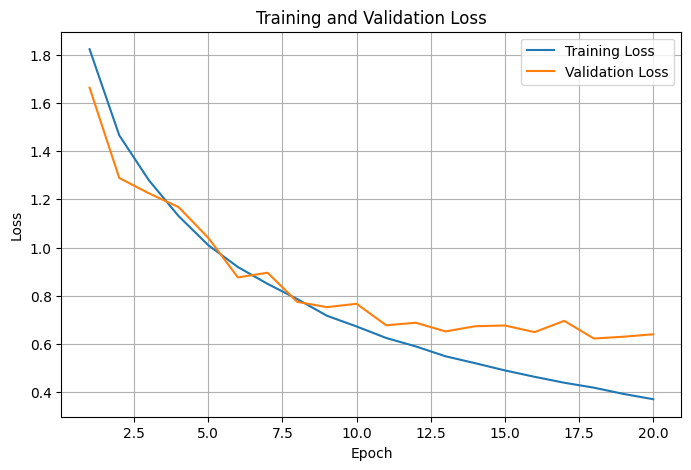

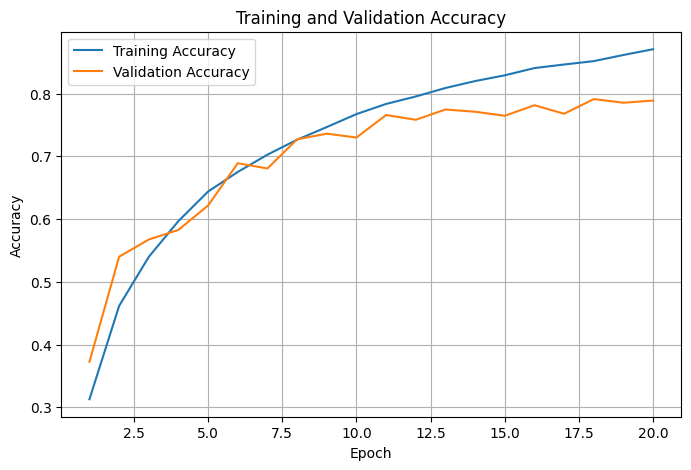

In [35]:
cnn_utils.plot_history(history_nin3)

In [36]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.6721
Test Accuracy: 0.7833
Test loss: 0.6721
Test accuracy: 78.33%


## NiN3 Results

NiN3 was trained for 20 epochs using the same training conditions as NiN2. The model contains three NiN blocks with **64, 128, and 256 channels** respectively.

### Training Results

The model showed steady improvement throughout the training period.

- Final training loss: **0.3710**
- Final validation loss: **0.6403**
- Final training accuracy: **87.07%**
- Final validation accuracy: **78.88%**

The training loss decreased steadily throughout the 20 epochs, while the validation loss also decreased overall but fluctuated during the later epochs.

Training accuracy increased from 31.28% in the first epoch to **87.07%** by the final epoch. Validation accuracy also increased substantially, reaching **78.88%** by the end of training.

The gap between training and validation accuracy became more noticeable as training progressed. This provides evidence of some overfitting, although the validation accuracy was still improving during the later epochs.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.6721**
- Test accuracy: **78.33%**

The test accuracy was close to the final validation accuracy of 78.88%.

### Observation

Compared with NiN2, increasing the depth from two NiN blocks to three blocks improved the test accuracy from **70.97% to 78.33%**.

The model also achieved higher training and validation accuracy than NiN2.

The training loss continued to decrease while training accuracy continued to increase throughout the experiment. Validation loss and validation accuracy showed some fluctuations in the later epochs, indicating that the model was beginning to fit the training data more strongly.

Overall, NiN3 demonstrated better performance on unseen data than NiN2 under the same training conditions.

These results will be compared with the deeper **NiN4** model to determine whether adding another NiN block produces further improvement.

## NiN4

NiN4 is the final model in the depth experiment. It contains **four NiN blocks** with 64, 128, 256, and 512 channels respectively.

The architecture is:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

This block is repeated four times, with the number of channels increasing from **64 → 128 → 256 → 512**.

### Purpose

The purpose of training NiN4 is to determine whether increasing the depth of the NiN architecture from three blocks to four blocks produces further improvements in learning and generalization.

All training conditions remain the same as NiN2 and NiN3:

- CIFAR-10 dataset
- Same train/validation split
- Same data augmentation
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Same weight initialization

The only architectural change is the addition of the fourth NiN block.

### NiN4 Configuration

| Model | Block 1 | Block 2 | Block 3 | Block 4 |
|---|---:|---:|---:|---:|
| NiN4 | 64 | 128 | 256 | 512 |

The results from NiN4 will be compared with NiN2 and NiN3 to determine how increasing the depth of the NiN architecture affects its performance on the CIFAR-10 test set.

In [37]:
model = NiN([64, 128, 256, 512])

In [38]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [40]:
model, history_nin4 = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7036 | Train Acc: 0.3644 | Val Loss: 1.4181 | Val Acc: 0.4759
Epoch [3/20] Train Loss: 1.0407 | Train Acc: 0.6248 | Val Loss: 0.9655 | Val Acc: 0.6522
Epoch [4/20] Train Loss: 0.8740 | Train Acc: 0.6949 | Val Loss: 0.8517 | Val Acc: 0.7016
Epoch [5/20] Train Loss: 0.7722 | Train Acc: 0.7281 | Val Loss: 0.8314 | Val Acc: 0.7051
Epoch [6/20] Train Loss: 0.6940 | Train Acc: 0.7580 | Val Loss: 0.7064 | Val Acc: 0.7480
Epoch [7/20] Train Loss: 0.6201 | Train Acc: 0.7839 | Val Loss: 0.7030 | Val Acc: 0.7579
Epoch [8/20] Train Loss: 0.5634 | Train Acc: 0.8046 | Val Loss: 0.6323 | Val Acc: 0.7863
Epoch [9/20] Train Loss: 0.5259 | Train Acc: 0.8188 | Val Loss: 0.6545 | Val Acc: 0.7751
Epoch [10/20] Train Loss: 0.4841 | Train Acc: 0.8320 | Val Loss: 0.6459 | Val Acc: 0.7770
Epoch [11/20] Train Loss: 0.4380 | Train Acc: 0.8469 | Val Loss: 0.6163 | Val Acc: 0.7912
Epoch [12/20] Train Loss: 0.3983 | Train Acc: 0.8610 | Val Loss: 0.5596 | Val Acc: 0.8095
Epoch [13/20] Trai

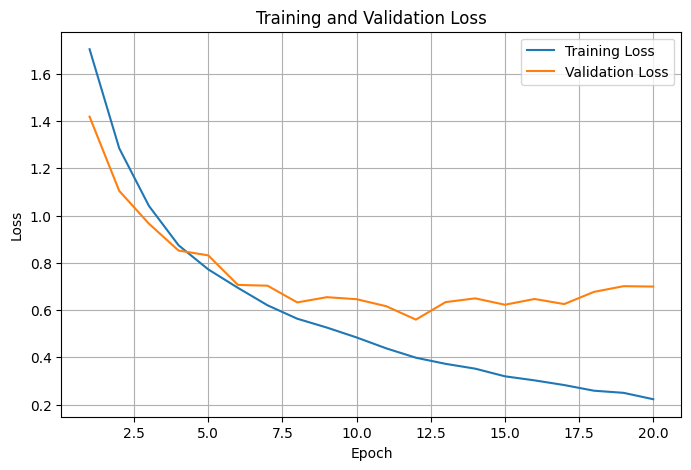

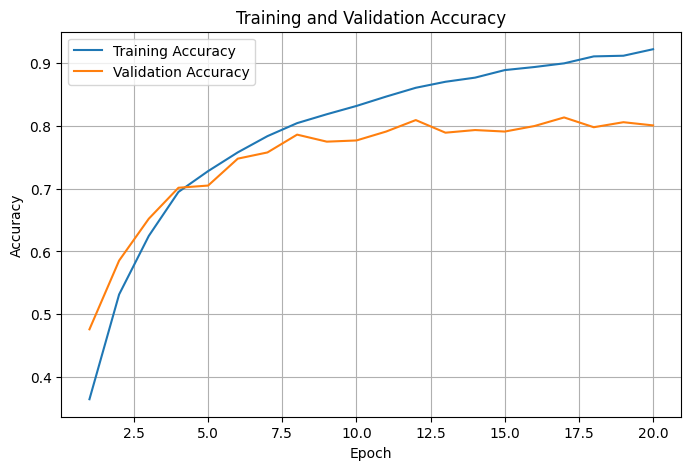

In [41]:
cnn_utils.plot_history(history_nin4)

In [42]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.7353
Test Accuracy: 0.7997
Test loss: 0.7353
Test accuracy: 79.97%


## NiN4 Results

NiN4 was trained for 20 epochs using the same training conditions as NiN2 and NiN3. The model contains four NiN blocks with **64, 128, 256, and 512 channels** respectively.

### Training Results

The model continued to improve strongly on the training data throughout the training period.

- Final training loss: **0.2227**
- Final validation loss: **0.6994**
- Final training accuracy: **92.25%**
- Final validation accuracy: **80.10%**

The training loss decreased smoothly throughout the 20 epochs, while the validation loss decreased during the early part of training and then began to fluctuate around the 0.6–0.7 range.

Training accuracy continued to increase throughout training, reaching 92.25%. In contrast, validation accuracy improved during the early and middle stages of training but began to plateau and fluctuate later in the training process.

The highest validation accuracy was approximately **81.37%** around epoch 17 before fluctuating during the remaining epochs.

The growing gap between training and validation accuracy provides evidence of overfitting. By the end of training, the training accuracy was 92.25%, while the validation accuracy was 80.10%, giving a gap of approximately 12 percentage points.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.7353**
- Test accuracy: **79.97%**

The test accuracy was very close to the final validation accuracy.

### Observation

Compared with NiN3, increasing the depth from three NiN blocks to four blocks improved the test accuracy from **78.33% to 79.97%**.

However, the improvement was relatively small compared with the improvement obtained when increasing the depth from NiN2 to NiN3.

The training accuracy continued to increase throughout the experiment, while validation accuracy began to plateau and fluctuate during the later epochs. Similarly, validation loss stopped showing consistent improvement while training loss continued to decrease.

This indicates that the additional depth allowed the model to fit the training data more strongly, but the improvement in generalization became smaller.

The results suggest that increasing NiN depth from two to four blocks improved test performance under the current training conditions, but the deeper NiN4 model also showed stronger evidence of overfitting.

## Experiment 2: Effect of Width

In this experiment, I will study how changing the width of the NiN network affects its performance on the CIFAR-10 classification task.

The depth of the network will be kept fixed at **three NiN blocks**. Each block contains:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

The only architectural variable that will be changed is the **number of channels in each block**.

### Width Configurations

| Model | Block 1 | Block 2 | Block 3 |
|---|---:|---:|---:|
| NiN3-Narrow | 32 | 64 | 128 |
| NiN3-Base | 64 | 128 | 256 |
| NiN3-Wide | 96 | 192 | 384 |

All other conditions will remain the same across the three models:

- CIFAR-10 dataset
- Same train/validation split
- Same data augmentation
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Same weight initialization
- Same three-block NiN architecture

The purpose of this experiment is to observe how increasing or decreasing the number of channels affects the learning behavior and generalization performance of the NiN architecture.

The results of the three width configurations will be compared using their training, validation, and test performance.

## NiN3-Narrow

NiN3-Narrow is the first model in the width experiment. The network depth is fixed at **three NiN blocks**, while the number of channels is reduced compared with the NiN3-Base model.

The architecture uses three NiN blocks with **32, 64, and 128 channels** respectively.

### NiN3-Narrow Configuration

| Model | Block 1 | Block 2 | Block 3 |
|---|---:|---:|---:|
| NiN3-Narrow | 32 | 64 | 128 |

The NiN block structure remains unchanged:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

The purpose of this model is to provide the narrow configuration for comparison with the **NiN3-Base** and **NiN3-Wide** models.

All training conditions remain the same across the three width configurations. The only architectural variable being changed is the number of channels.

In [43]:
model = NiN([32, 64, 128])

In [44]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [45]:
model, history_nin3_narrow = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8404 | Train Acc: 0.3077 | Val Loss: 1.6035 | Val Acc: 0.3885
Epoch [2/20] Train Loss: 1.5208 | Train Acc: 0.4419 | Val Loss: 1.5697 | Val Acc: 0.4580
Epoch [3/20] Train Loss: 1.3488 | Train Acc: 0.5066 | Val Loss: 1.2205 | Val Acc: 0.5573
Epoch [4/20] Train Loss: 1.2347 | Train Acc: 0.5559 | Val Loss: 1.1397 | Val Acc: 0.5897
Epoch [5/20] Train Loss: 1.1419 | Train Acc: 0.5917 | Val Loss: 1.1406 | Val Acc: 0.5937
Epoch [6/20] Train Loss: 1.0567 | Train Acc: 0.6221 | Val Loss: 1.0448 | Val Acc: 0.6321
Epoch [7/20] Train Loss: 0.9871 | Train Acc: 0.6507 | Val Loss: 0.9622 | Val Acc: 0.6570
Epoch [8/20] Train Loss: 0.9255 | Train Acc: 0.6745 | Val Loss: 0.8828 | Val Acc: 0.6827
Epoch [9/20] Train Loss: 0.8802 | Train Acc: 0.6882 | Val Loss: 0.8561 | Val Acc: 0.6974
Epoch [10/20] Train Loss: 0.8390 | Train Acc: 0.7032 | Val Loss: 0.8840 | Val Acc: 0.6926
Epoch [11/20] Train Loss: 0.7995 | Train Acc: 0.7205 | Val Loss: 0.8300 | Val Acc: 0.7080
Epoch [12/20] Train

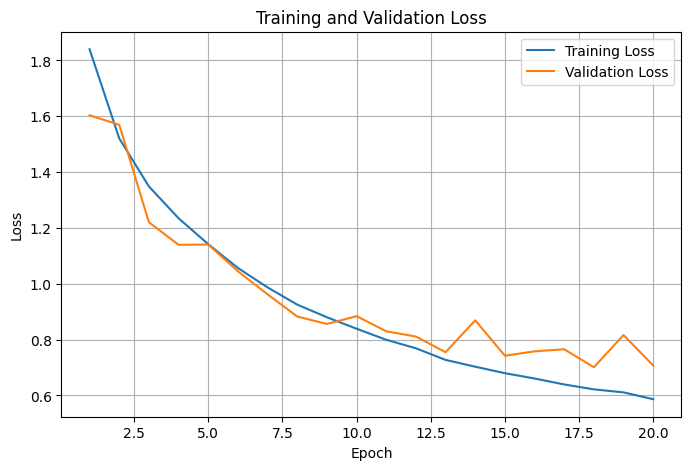

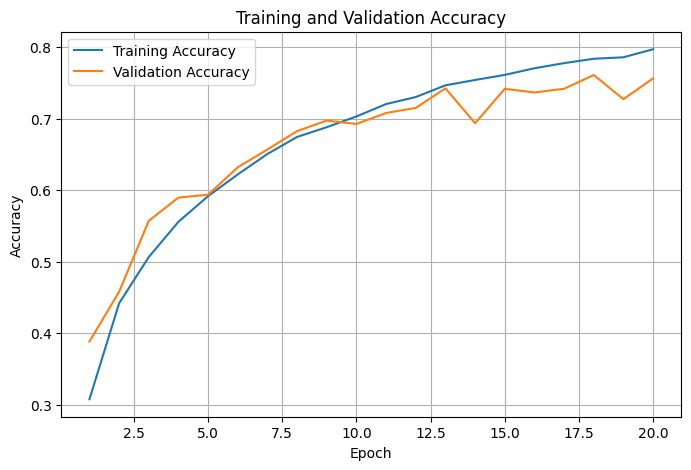

In [46]:
cnn_utils.plot_history(history_nin3_narrow)

In [47]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.7189
Test Accuracy: 0.7588
Test loss: 0.7189
Test accuracy: 75.88%


## NiN3-Narrow Results

NiN3-Narrow was trained for 20 epochs using the same training conditions as the other models in the width experiment. The network contains three NiN blocks with **32, 64, and 128 channels** respectively.

### Training Results

The model improved steadily throughout the training period.

- Final training loss: **0.5865**
- Final validation loss: **0.7070**
- Final training accuracy: **79.72%**
- Final validation accuracy: **75.64%**

The training loss decreased smoothly throughout the experiment. The validation loss also decreased overall, although it showed noticeable fluctuations during the later epochs.

Training accuracy increased from 30.77% in the first epoch to **79.72%** by the final epoch. Validation accuracy also improved throughout training, reaching **75.64%** at the end.

The gap between training and validation accuracy at the final epoch was approximately **4 percentage points**, indicating some overfitting but not a large separation between the two curves.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.7189**
- Test accuracy: **75.88%**

The test accuracy was very close to the final validation accuracy of 75.64%.

### Observation

NiN3-Narrow was able to learn the CIFAR-10 classification task with a relatively small number of channels, achieving **75.88% test accuracy**.

The training and validation curves followed a similar pattern, with both accuracies increasing and both losses decreasing overall. However, the validation curves fluctuated more during the later epochs.

The relatively small gap between training and validation accuracy suggests that the model did not show severe overfitting.

These results will serve as the narrow-width reference point for comparison with **NiN3-Base** and **NiN3-Wide**.

## NiN3-Base

NiN3-Base is the second model in the width experiment. The network depth remains fixed at **three NiN blocks**, while the number of channels is increased from the narrow configuration.

The architecture uses three NiN blocks with **64, 128, and 256 channels** respectively.

### NiN3-Base Configuration

| Model | Block 1 | Block 2 | Block 3 |
|---|---:|---:|---:|
| NiN3-Base | 64 | 128 | 256 |

The NiN block structure remains unchanged:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

The purpose of this model is to provide the base-width configuration for comparison with **NiN3-Narrow** and **NiN3-Wide**.

All training conditions remain the same across the three width configurations. The only architectural variable being changed is the number of channels.

The results will be compared with NiN3-Narrow to determine whether increasing the width of the network improves learning and generalization performance.

In [48]:
model = NiN([64, 128, 256])


In [49]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)


In [51]:
model, history_nin3_base = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8110 | Train Acc: 0.3210 | Val Loss: 1.4815 | Val Acc: 0.4598
Epoch [2/20] Train Loss: 1.4526 | Train Acc: 0.4682 | Val Loss: 1.2849 | Val Acc: 0.5219
Epoch [3/20] Train Loss: 1.2386 | Train Acc: 0.5511 | Val Loss: 1.1452 | Val Acc: 0.5872
Epoch [4/20] Train Loss: 1.0915 | Train Acc: 0.6097 | Val Loss: 0.9766 | Val Acc: 0.6600
Epoch [5/20] Train Loss: 0.9767 | Train Acc: 0.6524 | Val Loss: 0.9199 | Val Acc: 0.6696
Epoch [6/20] Train Loss: 0.8851 | Train Acc: 0.6877 | Val Loss: 0.9130 | Val Acc: 0.6693
Epoch [7/20] Train Loss: 0.8242 | Train Acc: 0.7084 | Val Loss: 0.8114 | Val Acc: 0.7155
Epoch [8/20] Train Loss: 0.7629 | Train Acc: 0.7329 | Val Loss: 0.7873 | Val Acc: 0.7190
Epoch [9/20] Train Loss: 0.7018 | Train Acc: 0.7545 | Val Loss: 0.7070 | Val Acc: 0.7548
Epoch [10/20] Train Loss: 0.6560 | Train Acc: 0.7708 | Val Loss: 0.7772 | Val Acc: 0.7353
Epoch [11/20] Train Loss: 0.6140 | Train Acc: 0.7860 | Val Loss: 0.7335 | Val Acc: 0.7455
Epoch [12/20] Train

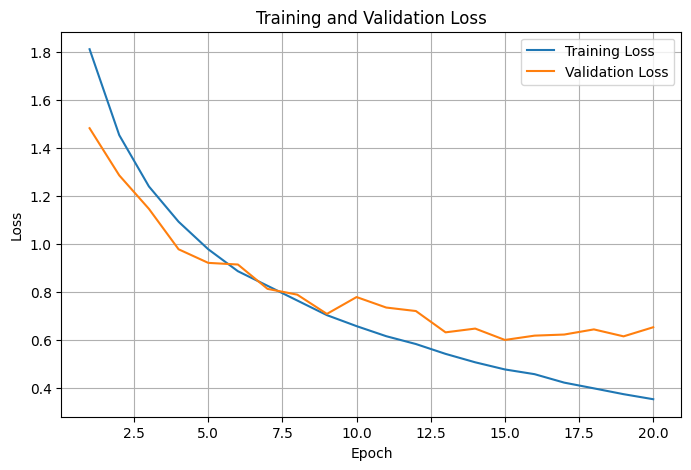

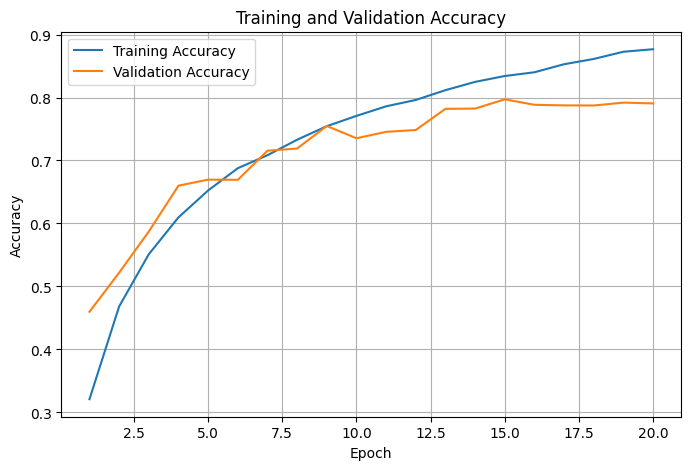

In [52]:
cnn_utils.plot_history(history_nin3_base)

In [53]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.6662
Test Accuracy: 0.7953
Test loss: 0.6662
Test accuracy: 79.53%


## NiN3-Base Results

NiN3-Base was trained for 20 epochs using the same training conditions as NiN3-Narrow. The network contains three NiN blocks with **64, 128, and 256 channels** respectively.

### Training Results

- Final training loss: **0.3511**
- Final validation loss: **0.6514**
- Final training accuracy: **86.71%**
- Final validation accuracy: **79.06%**

The training loss decreased steadily throughout the experiment, while the validation loss decreased overall but fluctuated during the later epochs.

Training accuracy increased steadily to 86.71%. Validation accuracy also improved, reaching 79.06%, although it began to fluctuate and level off during the later epochs.

The gap between training and validation accuracy at the final epoch was approximately **7.65 percentage points**, indicating some overfitting.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set.

- Test loss: **0.6662**
- Test accuracy: **79.53%**

The test accuracy was close to the final validation accuracy.

### Observation

Compared with NiN3-Narrow, increasing the number of channels from **32, 64, 128** to **64, 128, 256** improved the test accuracy from **75.88% to 79.53%**.

The Base model achieved higher training and validation accuracy than the Narrow model. However, the larger gap between training and validation accuracy also indicates increased overfitting.

These results will be compared with **NiN3-Wide** to determine whether increasing the width further produces additional improvement in generalization.

## NiN3-Wide

NiN3-Wide is the third and final model in the width experiment. The network depth remains fixed at **three NiN blocks**, while the number of channels is increased beyond the base configuration.

The architecture uses three NiN blocks with **96, 192, and 384 channels** respectively.

### NiN3-Wide Configuration

| Model | Block 1 | Block 2 | Block 3 |
|---|---:|---:|---:|
| NiN3-Wide | 96 | 192 | 384 |

The NiN block structure remains unchanged:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

The purpose of this model is to determine whether further increasing the number of channels improves the learning and generalization performance of the NiN architecture.

All training conditions remain the same as NiN3-Narrow and NiN3-Base. The only architectural variable being changed is the number of channels.

The results from NiN3-Wide will be compared with the Narrow and Base configurations to examine the effect of increasing network width.

In [54]:
model = NiN([96, 192, 384])

In [55]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [56]:
model, history_nin3_wide = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.7907 | Train Acc: 0.3239 | Val Loss: 1.6114 | Val Acc: 0.3969
Epoch [2/20] Train Loss: 1.4254 | Train Acc: 0.4791 | Val Loss: 1.2821 | Val Acc: 0.5307
Epoch [3/20] Train Loss: 1.2130 | Train Acc: 0.5591 | Val Loss: 1.1186 | Val Acc: 0.6028
Epoch [4/20] Train Loss: 1.0509 | Train Acc: 0.6235 | Val Loss: 0.9640 | Val Acc: 0.6522
Epoch [5/20] Train Loss: 0.9319 | Train Acc: 0.6688 | Val Loss: 0.8702 | Val Acc: 0.6959
Epoch [6/20] Train Loss: 0.8422 | Train Acc: 0.7027 | Val Loss: 0.8140 | Val Acc: 0.7116
Epoch [7/20] Train Loss: 0.7603 | Train Acc: 0.7345 | Val Loss: 0.7502 | Val Acc: 0.7315
Epoch [8/20] Train Loss: 0.6933 | Train Acc: 0.7580 | Val Loss: 0.7146 | Val Acc: 0.7531
Epoch [9/20] Train Loss: 0.6363 | Train Acc: 0.7759 | Val Loss: 0.6852 | Val Acc: 0.7635
Epoch [10/20] Train Loss: 0.5920 | Train Acc: 0.7928 | Val Loss: 0.6608 | Val Acc: 0.7748
Epoch [11/20] Train Loss: 0.5469 | Train Acc: 0.8094 | Val Loss: 0.6731 | Val Acc: 0.7620
Epoch [12/20] Train

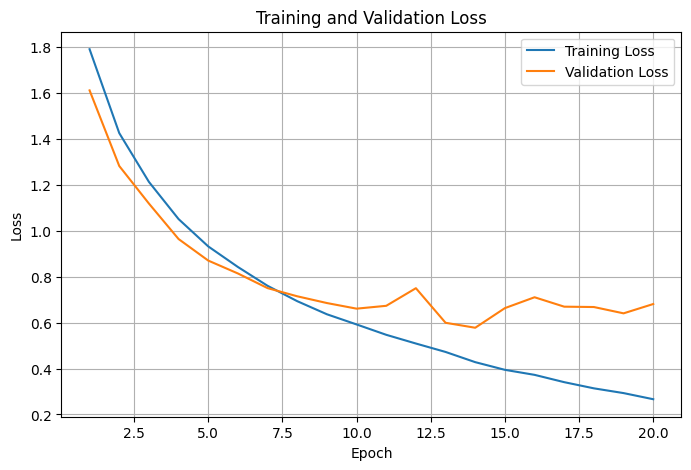

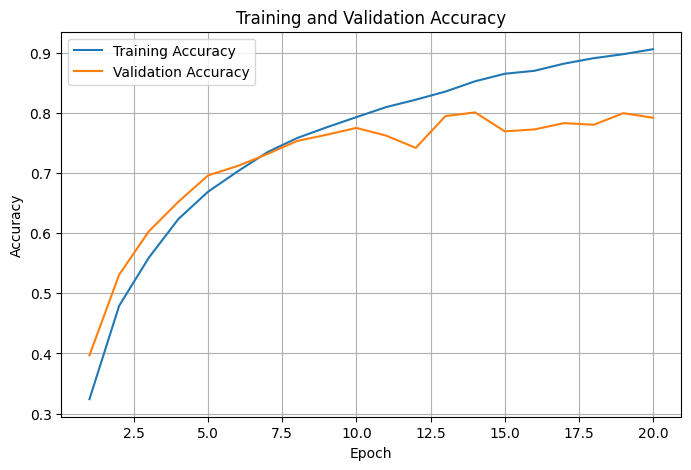

In [57]:
cnn_utils.plot_history(history_nin3_wide)

In [58]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.7204
Test Accuracy: 0.7883
Test loss: 0.7204
Test accuracy: 78.83%



## NiN3-Wide Results

NiN3-Wide was trained for 20 epochs using the same training conditions as NiN3-Narrow and NiN3-Base. The network contains three NiN blocks with **96, 192, and 384 channels** respectively.

### Training Results

The model continued to improve strongly on the training data throughout the experiment.

- Final training loss: **0.2663**
- Final validation loss: **0.6809**
- Final training accuracy: **90.56%**
- Final validation accuracy: **79.17%**

The training loss decreased smoothly throughout the 20 epochs. The validation loss decreased during the early stages of training but began to fluctuate during the later epochs.

Training accuracy continued to increase, reaching 90.56% at the final epoch. Validation accuracy improved during the early and middle stages of training but fluctuated during the later epochs, reaching 79.17% at the end.

The gap between training and validation accuracy at the final epoch was approximately **11.39 percentage points**, providing evidence of overfitting.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.7204**
- Test accuracy: **78.83%**

The test accuracy was close to the final validation accuracy.

### Observation

Compared with NiN3-Narrow, increasing the width from **32, 64, 128** to **96, 192, 384** increased the test accuracy from **75.88% to 78.83%**.

However, compared with NiN3-Base, which achieved **79.53% test accuracy**, the wider model achieved a slightly lower test accuracy of **78.83%**.

NiN3-Wide achieved a higher training accuracy than both the Narrow and Base configurations, but this did not translate into better test performance. The larger gap between training and validation accuracy also provides stronger evidence of overfitting.

These results suggest that increasing the width of the NiN architecture improved performance from the Narrow configuration to the Base configuration, but increasing the width further did not produce an additional improvement in generalization under the fixed training conditions.

## Experiment 3: Effect of Batch Normalization

In this experiment, I will study how adding **Batch Normalization** affects the training and generalization performance of the NiN architecture on the CIFAR-10 classification task.

The **NiN3-Base** architecture will be used as the fixed architecture for this experiment. It contains three NiN blocks with **64, 128, and 256 channels** respectively.

The original NiN3-Base block uses:

3×3 Conv → ReLU → 1×1 Conv → ReLU → 1×1 Conv → ReLU → MaxPool

The Batch Normalization version will use:

3×3 Conv → BatchNorm → ReLU  
1×1 Conv → BatchNorm → ReLU  
1×1 Conv → BatchNorm → ReLU  
MaxPool

### Models

| Model | Blocks | Channels | Batch Normalization |
|---|---:|---|---|
| NiN3-Base | 3 | 64, 128, 256 | No |
| NiN3-BN | 3 | 64, 128, 256 | Yes |

All other conditions will remain unchanged:

- CIFAR-10 dataset
- Same train/validation split
- Same data augmentation
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Same weight initialization

The only architectural change is the addition of **Batch Normalization**.

### Purpose

The purpose of this experiment is to observe how Batch Normalization affects the training behavior, convergence, validation performance, and test performance of the NiN architecture under the same training conditions.

In [59]:
class NiNBlockBN(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Conv2d):

                nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

In [60]:
class NiN_BN(nn.Module):

    def __init__(self, channels):
        super().__init__()

        blocks = []
        in_channels = 3

        for out_channels in channels:

            blocks.append(
                NiNBlockBN(
                    in_channels,
                    out_channels
                )
            )

            in_channels = out_channels

        self.blocks = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        linear_layer = self.classifier[2]

        nn.init.xavier_normal_(linear_layer.weight)
        nn.init.zeros_(linear_layer.bias)

    def forward(self, x):

        x = self.blocks(x)
        x = self.classifier(x)

        return x

In [61]:
model = NiN_BN([64, 128, 256])

In [62]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [63]:
model, history_nin3_bn = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.4088 | Train Acc: 0.4886 | Val Loss: 1.2013 | Val Acc: 0.5650
Epoch [2/20] Train Loss: 1.0300 | Train Acc: 0.6331 | Val Loss: 0.9697 | Val Acc: 0.6487
Epoch [3/20] Train Loss: 0.8650 | Train Acc: 0.6920 | Val Loss: 0.8395 | Val Acc: 0.6989
Epoch [4/20] Train Loss: 0.7507 | Train Acc: 0.7361 | Val Loss: 0.8506 | Val Acc: 0.7040
Epoch [5/20] Train Loss: 0.6651 | Train Acc: 0.7686 | Val Loss: 0.7201 | Val Acc: 0.7448
Epoch [6/20] Train Loss: 0.5853 | Train Acc: 0.7984 | Val Loss: 0.7852 | Val Acc: 0.7326
Epoch [7/20] Train Loss: 0.5472 | Train Acc: 0.8106 | Val Loss: 0.7031 | Val Acc: 0.7560
Epoch [8/20] Train Loss: 0.4962 | Train Acc: 0.8284 | Val Loss: 0.6783 | Val Acc: 0.7776
Epoch [9/20] Train Loss: 0.4461 | Train Acc: 0.8442 | Val Loss: 0.6538 | Val Acc: 0.7802
Epoch [10/20] Train Loss: 0.4174 | Train Acc: 0.8536 | Val Loss: 0.6616 | Val Acc: 0.7839
Epoch [11/20] Train Loss: 0.3876 | Train Acc: 0.8647 | Val Loss: 0.6029 | Val Acc: 0.8005
Epoch [12/20] Train

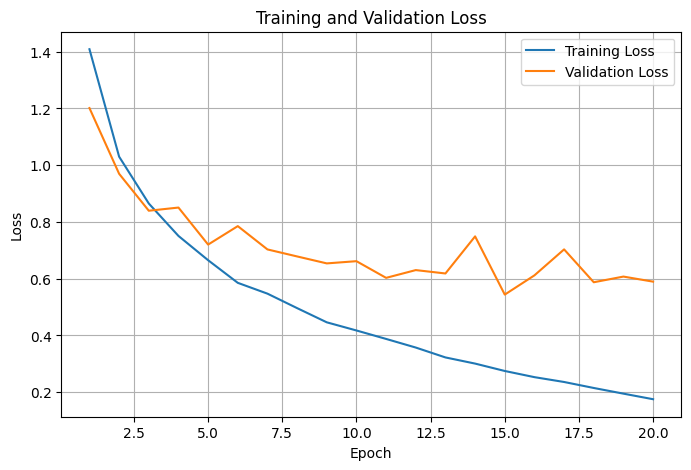

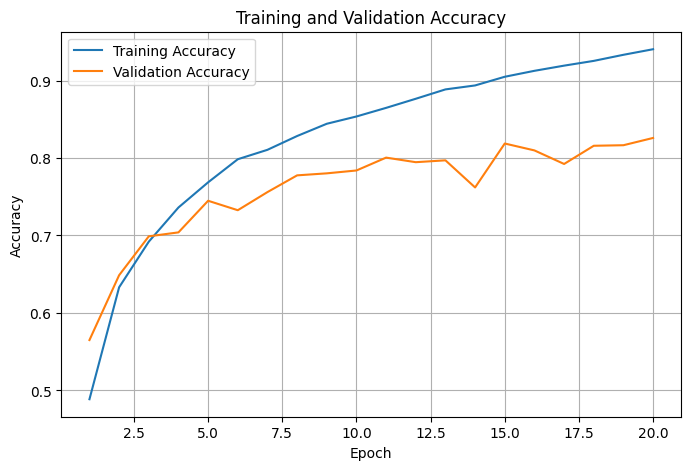

In [64]:
cnn_utils.plot_history(history_nin3_bn)

In [65]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.6323
Test Accuracy: 0.8157
Test loss: 0.6323
Test accuracy: 81.57%


## NiN3-BN Results

NiN3-BN was trained for 20 epochs using the same training conditions as NiN3-Base. The network contains three NiN blocks with **64, 128, and 256 channels**, with Batch Normalization added after each convolution and before the ReLU activation.

### Training Results

The model improved steadily on the training data throughout the experiment.

- Final training loss: **0.1751**
- Final validation loss: **0.5895**
- Final training accuracy: **94.04%**
- Final validation accuracy: **82.59%**

The training loss decreased smoothly throughout the experiment. The validation loss also decreased overall, although it fluctuated during the later epochs.

Training accuracy increased from 48.86% in the first epoch to **94.04%** by the final epoch. Validation accuracy also improved throughout training, reaching **82.59%** at the end.

The gap between training and validation accuracy at the final epoch was approximately **11.45 percentage points**, indicating evidence of overfitting. However, the model achieved better validation performance than the NiN3-Base model.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.6323**
- Test accuracy: **81.57%**

The test accuracy was close to the final validation accuracy of 82.59%.

### Observation

Compared with NiN3-Base, adding Batch Normalization improved the test accuracy from **79.53% to 81.57%**.

The NiN3-BN model also achieved higher training and validation accuracy than the NiN3-Base model.

Although the training accuracy reached 94.04%, the validation accuracy reached 82.59%, resulting in a noticeable generalization gap. Therefore, Batch Normalization did not eliminate overfitting, but under the fixed training conditions it was associated with improved performance on unseen data.

These results will be used to compare the NiN3-Base and NiN3-BN models and evaluate the effect of Batch Normalization on the NiN architecture.

# Overall Summary of NiN Architecture Experiments

The purpose of these experiments was to study how different architectural choices affect the learning and generalization behavior of a Network in Network (NiN) model on the CIFAR-10 classification task.

Three experiments were conducted:

1. Effect of Depth
2. Effect of Width
3. Effect of Batch Normalization

Throughout the experiments, the training conditions were kept constant unless the experiment specifically changed the architectural variable being studied.

---

## 1. Effect of Depth

The first experiment compared NiN models with two, three, and four NiN blocks.

| Model | Channels | Test Accuracy |
|---|---|---:|
| NiN2 | 64 → 128 | **70.97%** |
| NiN3 | 64 → 128 → 256 | **78.33%** |
| NiN4 | 64 → 128 → 256 → 512 | **79.97%** |

Increasing the depth from NiN2 to NiN3 produced a substantial improvement in test accuracy, from **70.97% to 78.33%**.

Increasing the depth further from NiN3 to NiN4 produced another improvement, but the improvement was much smaller, increasing test accuracy from **78.33% to 79.97%**.

The deeper models also showed increasing evidence of overfitting. NiN4 reached **92.25% training accuracy**, while its final validation accuracy was **80.10%**. The training accuracy continued to increase while validation performance began to fluctuate.

### Insight from Depth

Increasing depth improved the ability of the NiN architecture to learn the CIFAR-10 task, but the benefit became smaller as more blocks were added.

The deeper NiN4 model fitted the training data much more strongly, but this did not produce a proportionally large improvement on unseen data.

This suggests that increasing depth can improve representation capacity, but additional depth can also increase the gap between training and generalization performance.

---

## 2. Effect of Width

The second experiment kept the depth fixed at three NiN blocks and changed only the number of channels.

| Model | Channels | Test Accuracy |
|---|---|---:|
| NiN3-Narrow | 32 → 64 → 128 | **75.88%** |
| NiN3-Base | 64 → 128 → 256 | **79.53%** |
| NiN3-Wide | 96 → 192 → 384 | **78.83%** |

Increasing the width from the Narrow configuration to the Base configuration improved test accuracy from **75.88% to 79.53%**.

However, increasing the width further to the Wide configuration resulted in a slightly lower test accuracy of **78.83%**.

The Wide model achieved a higher training accuracy than the Narrow and Base models, but this did not translate into better test performance.

### Insight from Width

Increasing the number of channels initially improved the model's performance on unseen data.

However, making the network wider beyond the Base configuration did not produce a further improvement in test accuracy.

The Wide model fitted the training data more strongly, while its test performance was slightly lower than the Base model.

This suggests that simply increasing the number of channels does not guarantee better generalization.

---

## 3. Effect of Batch Normalization

The third experiment compared the three-block Base NiN architecture with and without Batch Normalization.

| Model | Batch Normalization | Test Accuracy |
|---|---|---:|
| NiN3-Base | No | **79.53%** |
| NiN3-BN | Yes | **81.57%** |

Adding Batch Normalization improved the test accuracy from **79.53% to 81.57%**.

The NiN3-BN model also achieved higher validation accuracy than the NiN3-Base model.

However, Batch Normalization did not eliminate overfitting. NiN3-BN reached **94.04% training accuracy** compared with **82.59% validation accuracy** at the final epoch.

### Insight from Batch Normalization

Under the training conditions used in this study, adding Batch Normalization improved the generalization performance of the NiN3-Base architecture.

However, the higher training accuracy compared with validation accuracy shows that Batch Normalization did not completely remove the gap between fitting the training data and generalizing to unseen data.

---

# Overall Findings

The three experiments provide several observations about the NiN architecture.

### 1. Depth increased performance, but with diminishing returns

NiN2 → NiN3 produced a large improvement in test accuracy.

NiN3 → NiN4 produced a much smaller improvement.

Therefore, adding more blocks increased model capacity, but the additional capacity produced progressively smaller gains on unseen data.

### 2. Width showed a similar pattern

Increasing width from Narrow to Base improved test performance.

Increasing width further from Base to Wide did not improve test performance.

The Base configuration therefore provided a stronger balance between model capacity and generalization under the fixed training conditions used in this experiment.

### 3. More capacity increased the ability to fit the training data

The deeper and wider models generally achieved higher training accuracy.

However, higher training accuracy did not always correspond to higher test accuracy.

This was particularly visible in the NiN4 and NiN3-Wide experiments.

### 4. Batch Normalization improved test performance

Adding Batch Normalization to the NiN3-Base architecture increased test accuracy from **79.53% to 81.57%**.

This shows that changing the internal behavior of the network, rather than simply increasing its depth or width, can also affect generalization performance.

### 5. Training and generalization must be considered together

Across the experiments, training accuracy alone was not enough to determine whether an architectural change was beneficial.

The validation and test results were important for determining whether additional model capacity translated into better performance on unseen data.

---

# Final Results

| Experiment | Model | Test Accuracy |
|---|---|---:|
| Depth | NiN2 | **70.97%** |
| Depth | NiN3 | **78.33%** |
| Depth | NiN4 | **79.97%** |
| Width | NiN3-Narrow | **75.88%** |
| Width | NiN3-Base | **79.53%** |
| Width | NiN3-Wide | **78.83%** |
| Batch Normalization | NiN3-Base | **79.53%** |
| Batch Normalization | NiN3-BN | **81.57%** |

Overall, these experiments show that the NiN architecture became more capable as depth and width were increased, but increasing model capacity did not always lead to better generalization. The experiments also showed that Batch Normalization improved test performance under the fixed training conditions used in this study.

The main purpose of these experiments was not to find the highest possible CIFAR-10 accuracy, but to understand how changes in CNN architecture affect learning behavior, overfitting, and generalization.